In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



In [17]:
##Preprocessing
df = pd.read_csv('Cleaned_df.csv')
# 1. Encoding
le = LabelEncoder()
df['country_enc'] = le.fit_transform(df['country'])
df['generation_enc'] = le.fit_transform(df['generation'])

# Select target variable and features(from regression to classification)
threshold = df['suicides/100k pop'].mean()
df['risk_level'] = (df['suicides/100k pop'] > threshold).astype(int)

features = ['country_enc', 'year', 'sex_numeric', 'new_age', 'population', 'gdp_billion', 'generation_enc']
X = df[features]
y = df['risk_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

mlp_model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer='adam', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])

print("Starting MLP training...")
history_mlp = mlp_model.fit(X_train_scaled, y_train, 
                            epochs=20, 
                            batch_size=32, 
                            validation_split=0.2, 
                            verbose=1)

print("MLP training completed!")

Starting MLP training...
Epoch 1/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7887 - loss: 0.4365 - val_accuracy: 0.8008 - val_loss: 0.4173
Epoch 2/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8053 - loss: 0.4055 - val_accuracy: 0.8124 - val_loss: 0.4043
Epoch 3/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8091 - loss: 0.3986 - val_accuracy: 0.8071 - val_loss: 0.4033
Epoch 4/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8142 - loss: 0.3919 - val_accuracy: 0.8181 - val_loss: 0.3938
Epoch 5/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8195 - loss: 0.3850 - val_accuracy: 0.8210 - val_loss: 0.3858
Epoch 6/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8204 - loss: 0.3793 - val_accuracy: 0.8241 - val_loss: 0.3772
Epoch 7/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8278 - loss: 0.3710 - val_accuracy: 0.8288 - val_loss: 0.3723
Epoch 8/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8313 - loss: 

174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report for MLP:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      3847
           1       0.76      0.74      0.75      1717

    accuracy                           0.85      5564
   macro avg       0.82      0.82      0.82      5564
weighted avg       0.85      0.85      0.85      5564



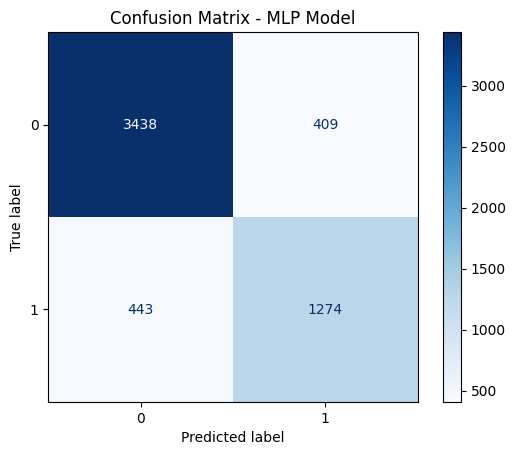

In [4]:
y_pred_mlp = (mlp_model.predict(X_test_scaled) > 0.5).astype("int32")

# Classification Report (Precision, Recall, F1-score)
print("Classification Report for MLP:")
print(classification_report(y_test, y_pred_mlp))

# 3.Confusion Matrix and Display
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - MLP Model")
plt.show()

In [ ]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

cnn_model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1], 1)),
    layers.Conv1D(32, kernel_size=2, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Starting CNN training...")
history_cnn = cnn_model.fit(X_train_cnn, y_train,epochs=20, batch_size=32, validation_split=0.2, verbose=1)

print(" CNN training completed!")

Starting CNN training...
Epoch 1/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7825 - loss: 0.4501 - val_accuracy: 0.7954 - val_loss: 0.4231
Epoch 2/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8029 - loss: 0.4133 - val_accuracy: 0.8093 - val_loss: 0.4178
Epoch 3/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8071 - loss: 0.4057 - val_accuracy: 0.8044 - val_loss: 0.4057
Epoch 4/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8089 - loss: 0.4010 - val_accuracy: 0.7904 - val_loss: 0.4144
Epoch 5/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8122 - loss: 0.3972 - val_accuracy: 0.7965 - val_loss: 0.4109
Epoch 6/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8142 - loss: 0.3930 - val_accuracy: 0.8050 - val_loss: 0.3974
Epoch 7/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8156 - loss: 0.3910 - val_accuracy: 0.8122 - val_loss: 0.3919
Epoch 8/20
557/557 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8154 - loss: 

174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report for CNN:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      3847
           1       0.71      0.72      0.72      1717

    accuracy                           0.83      5564
   macro avg       0.80      0.80      0.80      5564
weighted avg       0.83      0.83      0.83      5564



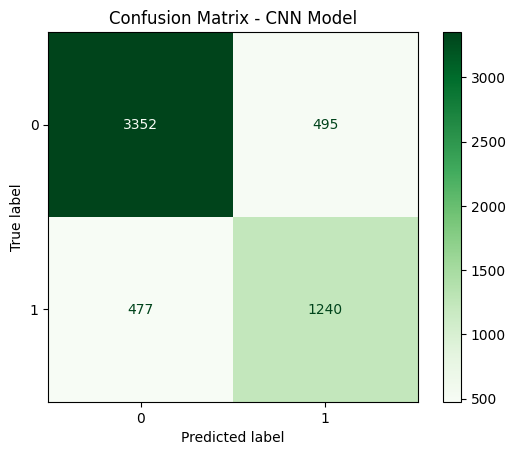

In [18]:
y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype("int32")

print("Classification Report for CNN:")
print(classification_report(y_test, y_pred_cnn))

# Confusion Matrix for CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn)
disp_cnn.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - CNN Model")
plt.show()

In [14]:
transfer_model = models.Sequential()
for layer in cnn_model.layers[:-2]: 
    transfer_model.add(layer)

transfer_model.trainable = False
transfer_model.add(layers.Dense(64, activation='relu'))
transfer_model.add(layers.Dropout(0.2)) 
transfer_model.add(layers.Dense(1, activation='sigmoid'))

transfer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Starting Transfer Learning training...")


transfer_model.fit(X_train_cnn, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
print(" Transfer Learning training completed!")

# Predictions for the transfer learning model
y_pred_transfer = (transfer_model.predict(X_test_cnn) > 0.5).astype("int32")

Starting Transfer Learning training...


e:\anaconda3\an\envs\keras_env\lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


 Transfer Learning training completed!
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


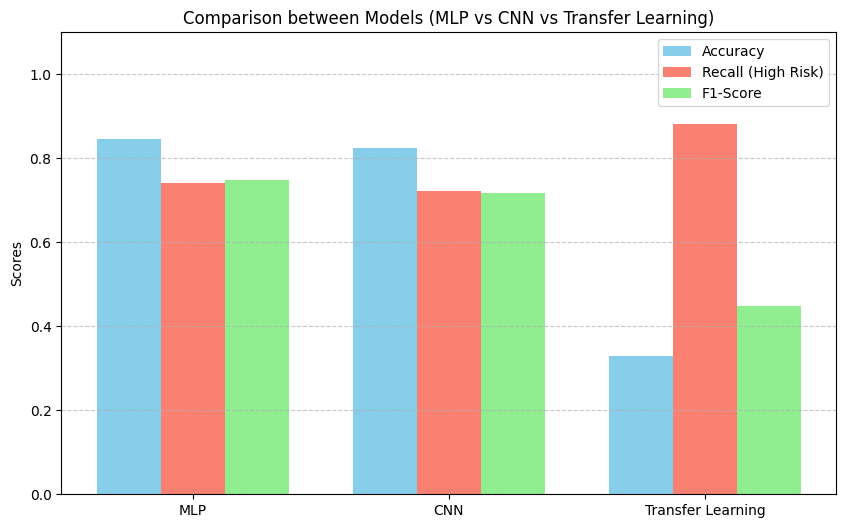

In [15]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

models_names = ['MLP', 'CNN', 'Transfer Learning']
accuracies = [accuracy_score(y_test, y_pred_mlp), accuracy_score(y_test, y_pred_cnn), accuracy_score(y_test, y_pred_transfer)]
recalls = [recall_score(y_test, y_pred_mlp), recall_score(y_test, y_pred_cnn), recall_score(y_test, y_pred_transfer)]
f1_scores = [f1_score(y_test, y_pred_mlp), f1_score(y_test, y_pred_cnn), f1_score(y_test, y_pred_transfer)]

x = np.arange(len(models_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, accuracies, width, label='Accuracy', color='skyblue')
ax.bar(x, recalls, width, label='Recall (High Risk)', color='salmon')
ax.bar(x + width, f1_scores, width, label='F1-Score', color='lightgreen')

ax.set_ylabel('Scores')
ax.set_title('Comparison between Models (MLP vs CNN vs Transfer Learning)')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.legend()
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
mlp_model.save('mlp_suicide_model.h5')
cnn_model.save('cnn_suicide_model.h5')
transfer_model.save('transfer_suicide_model.h5')
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Models and Scaler saved successfully!")

Models and Scaler saved successfully!
